# Is `1, 2, 3, 4, 5, 6` a Bad Lottery Guess?

## Information, entropy, and the lottery numbers my grandfather would not let me choose

> Working notebook for developing the story, calculations, and visualizations before turning it into a blog post.


## Six numbers for my grandfather

When I was a child, my grandfather played the lottery often. The game asked him to choose six numbers from 1 to 49, and sometimes he asked me to pick them.

I usually answered with something like

`1, 2, 3, 4, 5, 6`

or

`2, 4, 6, 8, 10, 12`.

I was teasing him. He knew it too. He would object, ask me to be serious, and refuse to waste money on my unserious guesses. To both of us, those numbers looked like jokes rather than possible lottery results.

My grandfather also believed that people were bad at choosing random numbers. He was right about that. We tend to avoid repetitions, spread numbers too evenly, and mistake a lack of visible patterns for randomness. I explored some of those habits in [an earlier post about randomness](../blog/randomness.html).

His solution was wonderfully practical. He made a small lottery of his own, drawing numbers from a bag as if he were playing bingo. The bag would choose without human bias. Surely that had to produce a better ticket.


## How many tickets are possible?

Years later, after studying statistics, mathematics, and physics, I saw the puzzle differently. A 6-from-49 lottery has

$$
\binom{49}{6} = \frac{49!}{6!43!} = 13{,}983{,}816
$$

possible tickets. Order does not matter, and a number cannot appear twice.


In [5]:
from math import comb, log2

total_tickets = comb(49, 6)
ticket_probability = 1 / total_tickets
ticket_information = -log2(ticket_probability)

print(f"Possible tickets: {total_tickets:,}")
print(f"Chance for one ticket: 1 in {total_tickets:,}")
print(f"Information in one fair draw: {ticket_information:.2f} bits")


Possible tickets: 13,983,816
Chance for one ticket: 1 in 13,983,816
Information in one fair draw: 23.74 bits


A fair lottery gives every one of those tickets the same probability.

`1, 2, 3, 4, 5, 6` has a 1 in 13,983,816 chance.

`2, 8, 11, 16, 42, 48` also has a 1 in 13,983,816 chance.

My joke was a perfectly valid guess. Grandpa's bag could choose a more random-looking ticket, but the lottery machine gave that ticket the same chance as mine.

This is where semantics starts to matter. What does `1, 2, 3, 4, 5, 6` represent in the comparison? It can mean one exact ticket. It can also stand for a broader idea such as 'a recognizable sequence.' Those are different events with different probabilities.


## One exact ticket versus a family of sequences

Compared as exact tickets, `1, 2, 3, 4, 5, 6` and `2, 8, 11, 16, 42, 48` are equally likely. Compared as representatives of two families, recognizable sequences are much rarer than combinations without a recognizable sequence. Our intuition quietly moves from the first comparison to the second.

There is only one ticket equal to `1, 2, 3, 4, 5, 6`. There are 44 tickets made from six consecutive numbers:

`1, 2, 3, 4, 5, 6`

`2, 3, 4, 5, 6, 7`

and so on, up to

`44, 45, 46, 47, 48, 49`.

So the probability that the winning numbers form any consecutive run is

$$
P(\text{six consecutive}) = \frac{44}{\binom{49}{6}}
= \frac{1}{317{,}814}.
$$

That is rare: about 0.000315%.

The probability that the winning numbers are not consecutive is

$$
1 - \frac{44}{\binom{49}{6}} \approx 99.999685\%.
$$

One particular messy-looking ticket has the same probability as `1, 2, 3, 4, 5, 6`. The giant family of non-consecutive tickets has much more probability than the small family of consecutive tickets because it contains many more individual tickets.

So the sentence '`1, 2, 3, 4, 5, 6` is less likely' can be true or false depending on what it means. It is false when we compare that exact ticket with another exact ticket. It is true when the sequence stands for a small, precisely defined family and we compare that family with its much larger complement.


## What about `2, 4, 6, 8, 10, 12`?

That ticket is an arithmetic progression. Each number is separated from the next by the same step. In a 6-from-49 lottery, there are 216 six-number arithmetic progressions in total. The step can range from 1 to 9, with fewer possible starting points as the step gets larger.

$$
44 + 39 + 34 + 29 + 24 + 19 + 14 + 9 + 4 = 216.
$$

The chance that the winning ticket is one of these arithmetic progressions is about 1 in 64,740. Again, each particular progression has exactly the same chance as each particular irregular ticket.


In [6]:
n, k = 49, 6
consecutive_tickets = n - k + 1
progression_tickets = sum(n - (k - 1) * step for step in range(1, (n - 1) // (k - 1) + 1))
nonconsecutive_tickets = comb(n, k) - consecutive_tickets

categories = {
    "One exact ticket": 1,
    "Any six consecutive numbers": consecutive_tickets,
    "Any six-term arithmetic progression": progression_tickets,
    "Any non-consecutive ticket": nonconsecutive_tickets,
}

for name, count in categories.items():
    probability = count / total_tickets
    print(f"{name:38s} {count:>10,} tickets   P = {probability:.8%}")


One exact ticket                                1 tickets   P = 0.00000715%
Any six consecutive numbers                    44 tickets   P = 0.00031465%
Any six-term arithmetic progression           216 tickets   P = 0.00154464%
Any non-consecutive ticket             13,983,772 tickets   P = 99.99968535%


## Visualizing the number of microstates

The categories differ by so many orders of magnitude that a logarithmic scale is more useful than a regular bar chart. Arithmetic progressions include consecutive runs, so these bars should be read as separate comparisons rather than pieces of one partition.


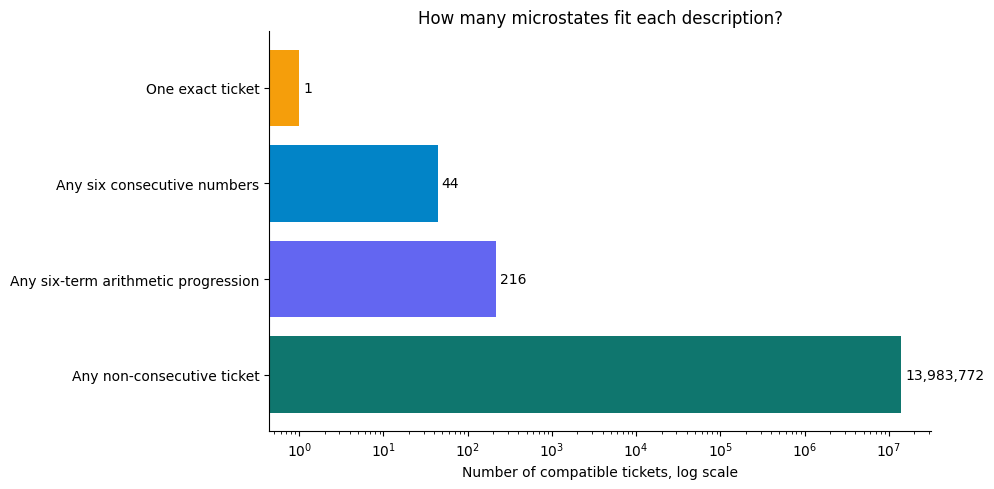

In [7]:
import matplotlib.pyplot as plt

labels = list(categories.keys())
counts = list(categories.values())
colors = ["#f59e0b", "#0284c7", "#6366f1", "#0f766e"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, counts, color=colors)
ax.set_xscale("log")
ax.set_xlabel("Number of compatible tickets, log scale")
ax.set_title("How many microstates fit each description?")
ax.invert_yaxis()

for bar, count in zip(bars, counts):
    ax.text(count * 1.12, bar.get_y() + bar.get_height() / 2, f"{count:,}", va="center")

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Microstates, macrostates, and entropy

Physics gives us useful language for this counting problem.

A **microstate** is one exact ticket. `1, 2, 3, 4, 5, 6` is one microstate. So is `7, 13, 22, 34, 41, 48`.

A **macrostate** groups many microstates under one description. 'Six consecutive numbers' is a macrostate containing 44 tickets. 'Numbers that are not consecutive' is a much larger macrostate containing 13,983,772 tickets.

Boltzmann's entropy counts how many microstates fit a macrostate:

$$
S = k_B \ln W.
$$

The quantity $W$ is the number of compatible microstates. Larger $W$ means larger entropy. If we compare the two categories, the non-consecutive macrostate wins overwhelmingly because almost every possible ticket belongs to it.

This is close to what our eyes do when they see lottery numbers. We recognize `1, 2, 3, 4, 5, 6` as a member of a tiny, easy-to-name family. A messy-looking result gets dropped into a huge catch-all family. We compare the families even when the original question asked us to compare two individual tickets.

The phrase 'recognizable sequence' has no single mathematical definition. It might mean six consecutive numbers, any six-term arithmetic progression, only odd numbers, shared final digits, or a shape on the playslip. Someone else may notice a pattern that means nothing to me. These categories can also overlap.

We only get a probability after choosing a rule and counting how many tickets satisfy it. Six consecutive numbers gives us 44 microstates. Six-term arithmetic progressions gives us 216. A broader definition of recognizable patterns would give us more. The semantic choice determines the macrostate, and the macrostate determines the count.


## Information gives us another view

Shannon measured the information in an event as

$$
I(x) = -\log_2 P(x).
$$

Under a fair lottery model, each exact ticket carries about 23.74 bits of information because each has the same probability.

We can also ask about a category. Learning that the result was six consecutive numbers would carry about 18.28 bits of information because that event happens only once in 317,814 draws. Learning that the result was non-consecutive tells us almost nothing because nearly every draw has that property.

Patterns also give us shorter descriptions. 'The first six positive integers' is an easy way to communicate `1, 2, 3, 4, 5, 6`. An irregular ticket may be easiest to communicate by listing every number. This idea is often called description length or algorithmic complexity. Short descriptions feel planned. Long, awkward descriptions feel random.

These ideas meet in the same place. Entropy counts the size of a family, Shannon information measures surprise under a probability model, and description length captures how simply we can state an outcome. The meaning we assign to `1, 2, 3, 4, 5, 6` decides which probability question we are asking. That is why the same sequence can be an ordinary individual ticket and an unusual kind of result at the same time.


## Try the macrostate explorer

This small widget lets us switch between several descriptions and see how many tickets fit each one. It is a first prototype. If it adds something to the explanation, we can rebuild it for the website later.


In [8]:
import ipywidgets as widgets
from IPython.display import display

macrostate_counts = {
    "One exact ticket": 1,
    "Six consecutive numbers": consecutive_tickets,
    "Six-term arithmetic progression": progression_tickets,
    "Numbers that are not consecutive": nonconsecutive_tickets,
}

selector = widgets.Dropdown(
    options=list(macrostate_counts),
    value="Six consecutive numbers",
    description="Description:",
    style={"description_width": "initial"},
)
result = widgets.HTML()

def update_macrostate(change=None):
    count = macrostate_counts[selector.value]
    probability = count / total_tickets
    odds = total_tickets / count
    information = -log2(probability)
    result.value = (
        f"<b>Compatible microstates:</b> {count:,}<br>"
        f"<b>Probability:</b> {probability:.8%}<br>"
        f"<b>About 1 in:</b> {odds:,.1f}<br>"
        f"<b>Shannon information:</b> {information:.2f} bits"
    )

selector.observe(update_macrostate, names="value")
update_macrostate()
display(widgets.VBox([selector, result]))


## What did the bag improve?

The bag solved the problem my grandfather wanted to solve. It removed his habits from the selection process and produced combinations without a human preference for certain numbers or shapes.

For the actual jackpot, the lottery machine only cared about the ticket he held. Once he had one valid combination, there was exactly one winning draw that matched it among 13,983,816 possibilities. His personal method for arriving at that ticket did not change that count.

That is the part I missed as a child. My sequence looked like a bad attempt at randomness because it was easy to describe and belonged to a tiny family of obvious patterns. It remained one valid ticket among millions.


## The question I never got to ask

I still wonder what would have happened if my grandfather's homemade lottery had dropped `1, 2, 3, 4, 5, 6` onto the table.

Would he have played them?

I guess we will never know. :D


## Notes for the next iteration

- Read the draft aloud and shorten any passages that sound like a textbook.
- Decide whether the arithmetic-progression section adds enough beyond the consecutive example.
- Run the visualization and adjust its labels and colors.
- Test whether the macrostate explorer feels useful or merely repeats the table.
- Consider adding a small visual with 44 consecutive tickets on one side and a sample of the much larger non-consecutive family on the other.
